## DBSCAN密度聚类案例（一）
+ 实现下列指定的数据集聚类
+ 要求：聚成内、中、外三类

### 第1步、生成数据集

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

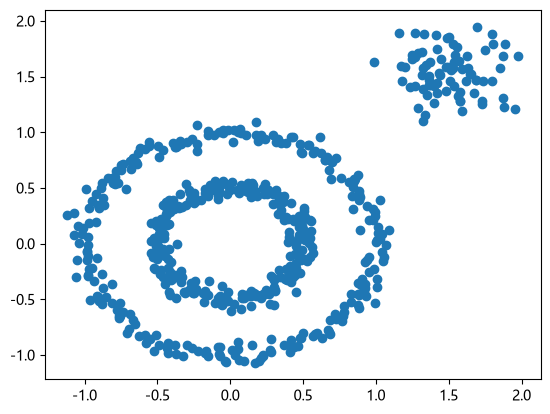

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# 生成环形数据集（500个样本）
X1, y1 = datasets.make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=0)

# 生成点块数据集（80个样本）
X2, y2 = datasets.make_blobs(n_samples=80, centers=[[1.5, 1.5]], cluster_std=0.2, random_state=0)

# 合并成一个数据集，生成散点图
X = np.concatenate([X1, X2])
plt.scatter(X[:, 0], X[:, 1], marker='o')
plt.show()


### 第2步 尝试用KMeans、MeanShift、Birch聚成3类

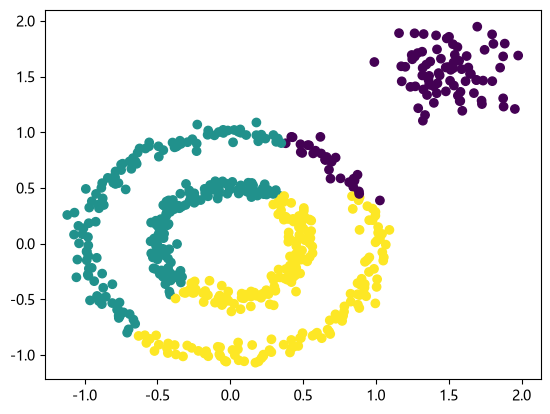

In [3]:
from sklearn.cluster import KMeans, MeanShift, Birch

# 尝试三种聚类模型，都不能达到目的
y_pred = KMeans(n_clusters=3, n_init=10, random_state=0).fit_predict(X) # KMeans
# y_pred = Birch(n_clusters=3).fit_predict(X) # Birch
# y_pred = MeanShift().fit_predict(X) # MeanShift

plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.show()


### 第3步、使用DBSCAN算法，不指定参数

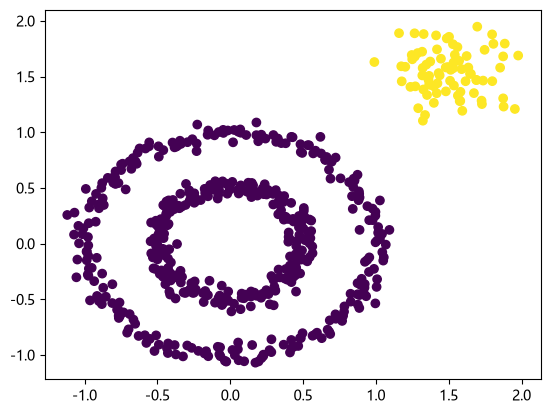

In [4]:
from sklearn.cluster import DBSCAN

# 使用无参数的DBSCAN聚类，发现模型将所有样本归为了一类
y_pred = DBSCAN().fit_predict(X)

# 画散点图
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.show()


### 第4步 指定DBSCAN模型的参数
+ eps-临近半径
+ min_samples-最小样本数

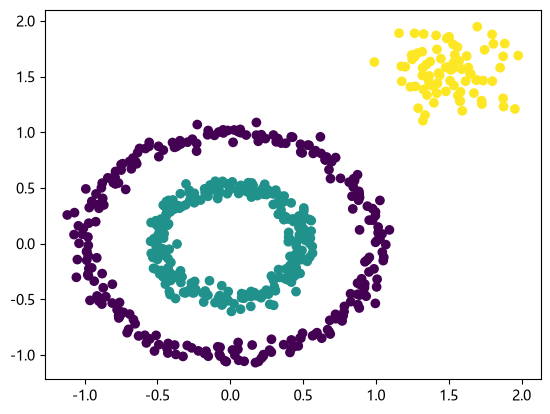

In [5]:
# 指定参数，调参，任务完成（聚成内、中、外3类）
y_pred = DBSCAN(eps=0.2, min_samples=5).fit_predict(X)

# 画散点图
plt.scatter(X[:, 0], X[:, 1], c=y_pred)

plt.show()
